# Sieci neuronowe ze splotem (konwolucyjne)

Dzisiaj poznamy prawdopodobnie najpopularniejszy model sieci neuronowej zaprojektowany do klasyfikacji obrazków wszelkiego rodzaju, a bardziej precyzyjnie: do wszelkich danych, w których istotna jest zależność przestrzenna. Zbudujemy przykładową sieć ze splotem (convolutional neural network, CNN) 

Dodatkowo użyjemy techniki wzbogacania zbioru danych - `data augmentation`
Technika polega na generowaniu dodatkowych danych z istniejącego zestawu, bazując na prostych transformacjach - rotacjach, przerzucaniu, podkreślaniu krawędzi, itd. 

Będziemy pracować na zbiorze MNIST, czyli zbiorze czarno-białych obrazków z ręcznie napisanymi cyframi.

## Przygotowanie środowiska programistycznego

By zapewnić powtarzalność wyników ustawiany ziarno generatora liczb losowych:
```Python
seed = 128
rng = np.random.RandomState(seed)
```

In [45]:
import sys, os

from termcolor import colored
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torchvision import datasets
from torch import nn

seed = 128
rng = np.random.default_rng(seed=seed)


Tak jak na poprzednich zajęciach - ustalamy na jakim urządzeniu liczymy (gpu/cpu) i jaki format danych chcemy wykorzystać.

In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
dtype = torch.float32

Using device: cuda


## Import danych MNIST

In [47]:
train_data = datasets.MNIST(
    root='./data/', # Lokalizacja do przechowania danych
    train=True, # chcemy zbiór treningowy
    download=True, # jeżeli jeszcze nie są pobrane, to pobieramy
    transform=transforms.ToTensor(), # zdjęcia przekształcamy do tensorów. Uwaga! transformacja automatycznie skaluje obrazki do [0,1]!
    target_transform=None # you can transform labels as well
)
# Setup testing data
test_data = datasets.MNIST(
    root='./data/',
    train=False, # jak nie chcemy zbiory treningowego, to znaczy że chcemy testowy
    download=True,
    transform=transforms.ToTensor()
)

# Analiza zbioru danych

Zerknijmy na pierwszy przykład

Image shape: torch.Size([1, 28, 28]), Label: 5


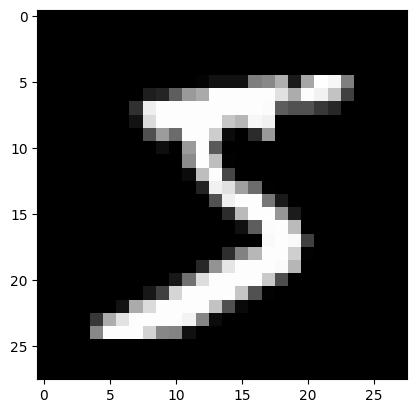

In [48]:
idx = 0
image, label = train_data[idx]
image, label
print(f"Image shape: {image.shape}, Label: {label}") # Co oznacza pierwszy wymiar obrazu?
plt.imshow(image.squeeze(), cmap="gray");

Jakie mamy klasy?

In [49]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [50]:
print(f"Nasz przykład z obrazka o indeksie {idx} jest przypisany do klasy {class_names[label]}")

Nasz przykład z obrazka o indeksie 0 jest przypisany do klasy 5 - five


Ile mamy danych?

In [51]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

## Dataset vs DataLoader — czym się różnią?

### **Dataset**
**Dataset** to obiekt, który przechowuje dane oraz informację o tym, jak mają być wczytywane i przekształcane.  
W PyTorchu dataset:
- przechowuje pary *(x, y)*, czyli dane oraz etykiety,
- implementuje metody `__len__()` i `__getitem__()`,
- może zawierać transformacje, np. konwersję do tensora lub augmentacje.

Dataset MNIST zwraca obrazek (tensor) oraz jego etykietę (cyfrę 0–9).

---

### **DataLoader**
**DataLoader** to narzędzie, które opakowuje dataset i umożliwia efektywne wczytywanie danych podczas trenowania modeli.
Odpowiada za:
- dzielenie danych na **batch'e**,
- mieszanie danych (*shuffling*),
- równoległe pobieranie danych (`num_workers`),
- wygodne iterowanie po danych w pętli treningowej.

Dzięki DataLoaderowi model trenuje w porcjach danych, co zwiększa wydajność i stabilność treningu.

Załadujmy więc teraz nasz Dataset do DataLoader:

In [52]:

BATCH_SIZE = 8 # Określa ile przykładów  będzie w jednej paczce (batchu), na podstawie której model będzie aktualizował swoje wagi

train_dataloader = DataLoader(train_data,
    batch_size=BATCH_SIZE, 
    shuffle=True # Zawsze trzeba pamiętać aby podczas treningu model dostawał próbki w losowej kolejności, to może mieć duży wpływ na jakość treningu.
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # Przy ewaluacji modelu to nie ma znaczenia, więc nie warto na to tracić czasu.
)

Sprawdźmy jak wygląda DataLoader

In [53]:
print(f"Długość dataloadera treningowego: {len(train_dataloader)} dla batch size = {BATCH_SIZE}")
print(f"Długość dataloadera testowego: {len(test_dataloader)} dla batch size = {BATCH_SIZE}")

Długość dataloadera treningowego: 7500 dla batch size = 8
Długość dataloadera testowego: 1250 dla batch size = 8


DataLoader jest generatorem, więc żeby dobrać się do pierwszej próbki trzeba to zrobić w następujący sposób:

In [54]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([8, 1, 28, 28]), torch.Size([8]))

## Warstwa konwolucyjna `nn.Conv2d`

W zadaniach związanych z analizą obrazów bardzo często wykorzystuje się **warstwy konwolucyjne**.  
W PyTorchu odpowiada za nie moduł **`nn.Conv2d`**, który wykonuje operację konwolucji na obrazach 2D.

Przykład utworzenia warstwy:
```python
conv = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
```

---

## Podstawowe parametry warstwy `Conv2d`

### **1. `in_channels` — liczba kanałów na wejściu**
- określa, ile kanałów ma obraz wchodzący do warstwy,
- dla zdjęć RGB: `in_channels = 3`,
- dla MNIST (obrazy w skali szarości): `in_channels = 1`.

Warstwa musi znać liczbę kanałów, aby dobrać odpowiednie filtry.

---

### **2. `out_channels` — liczba filtrów / map cech**
- określa, ile filtrów (kernelów) stworzy warstwa,
- każdy filtr generuje jedną *mapę cech* („feature map”).

Więcej filtrów = więcej różnorodnych wykrywanych wzorców  
(np. krawędzie pionowe, poziome, tekstury itp.).

---

### **3. `kernel_size` — rozmiar filtra**
- określa wymiary filtra (np. `3`, `5` lub `(3,5)`),

Filtr skanuje obraz i wykrywa lokalne wzorce.

---

### **4. `stride` — krok przesuwania filtra**
- mówi, o ile pikseli przesuwamy filtr przy kolejnych obliczeniach,
- domyślnie `stride=1`,
- większy stride → mniejszy rozmiar wyjścia (bardziej agresywna redukcja).

Przykład:
```python
nn.Conv2d(1, 32, kernel_size=3, stride=2)
```

---

### **5. `padding` — „ramka” dookoła obrazu**
- dodaje wirtualne piksele wokół obrazu,
- najczęściej ustawia się `padding=1` przy `kernel_size=3`,
- pomaga zachować wymiary wejścia.

Bez paddingu obraz po konwolucji „maleje”.

Przykład:  
`28x28` → (kernel 3, stride 1, **bez paddingu**) → `26x26`  
`28x28` → (kernel 3, stride 1, **padding=1**) → `28x28`

---

## Krótki przykład warstwy konwolucyjnej

```python
conv = nn.Conv2d(
    in_channels=1,   # obraz MNIST: 1 kanał
    out_channels=16, # 16 filtrów
    kernel_size=3,   # filtr 3x3
    stride=1,
    padding=1        # zachowujemy wymiary wejściowe
)
```

Taka warstwa przyjmie tensor **[batch, 1, 28, 28]**  
i zwróci tensor **[batch, 16, 28, 28]**.

---

Poniżej dokładne zilustrowanie na czym polega konwolucja:

Warstwa konwolucyjna dokonuje splotu na danych wejściowych (zielony rysunek) z filtrem (czerwone wartości w żółtym kwadracie).  Jako wynik zwraca nowe dane (różowy rysunek). Żółta macierz przesuwająca się po zielonym obrazku (z czerwonymi elementami, które się nie zmieniają) to filtr lub jądro. 

Wielkości modyfikowane w ramach treningu to wartości wag filtra pozostałe wielkości to hiperparametry.
W sytuacji kiedy kanałów jest więcej niż jeden, wartości dla wszystkich kanałów są domyślnie sumowane dla danego piksela. Zwykle każda warstwa splotu zawiera wiele filtrów, czyli wiele wariantów wartości wag.


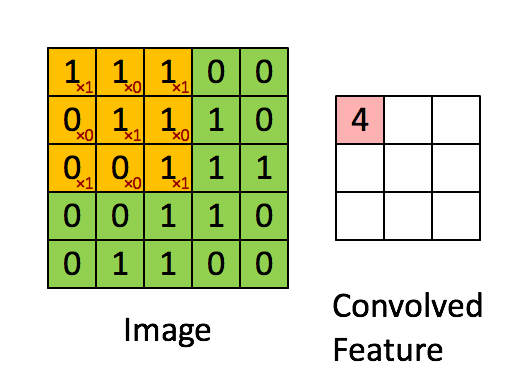

## Pooling — MaxPooling i AveragePooling

Pooling to operacja zmniejszająca rozmiar obrazu (lub map cech) przy jednoczesnym zachowaniu najważniejszych informacji.  
Najczęściej stosuje się ją po warstwach konwolucyjnych, aby:

- zmniejszyć liczbę parametrów,
- zwiększyć odporność na przesunięcia,
- skrócić czas obliczeń.

---

## **MaxPooling**
**MaxPooling** wybiera **maksymalną wartość** z każdego okna (np. 2×2).  
Działa jak „najsilniejsza aktywacja” w danym fragmencie.

Przykład:
```python
pool = nn.MaxPool2d(kernel_size=2, stride=2)
```

Efekt:
- wejście: `[batch, channels, 28, 28]`
- wyjście: `[batch, channels, 14, 14]`

MaxPooling zachowuje najważniejsze (najmocniej aktywne) cechy.

---

## **AveragePooling**
**AveragePooling** zwraca **średnią wartość** z okna.

Przykład:
```python
pool = nn.AvgPool2d(kernel_size=2, stride=2)
```

Daje gładsze, mniej agresywne zmniejszenie wymiarów.

---

Pooling nie ma parametrów uczonych — to stała operacja zmniejszania wymiarów.
Operacja "pooling" jest wykonywana dla każdego kanału oddzielnie.



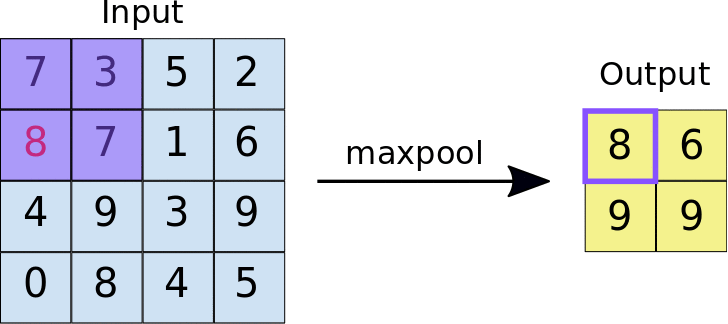

## Warstwa Dropout

**Dropout** to technika regularizacji, która pomaga zapobiegać przeuczeniu (overfittingowi).  
Polega na tym, że podczas trenowania **losowo “wyłączany” jest procent neuronów** w warstwie — tzn. ich wyjścia są ustawiane na zero.

Dzięki temu:
- model nie polega zbyt mocno na pojedynczych neuronach,
- sieć uczy się bardziej ogólnych, odpornych reprezentacji,
- poprawia się zdolność generalizacji.

---

## Jak działa Dropout?

Podczas **treningu**:
- losowo zeruje np. 20%–50% aktywacji,
- każdorazowo wybiera inne neurony.

Podczas **testowania**:
- dropout jest automatycznie wyłączany,
- wartości są skalowane tak, aby zachować oczekiwany poziom aktywacji.

---

## Przykład użycia w PyTorch

```python
drop = nn.Dropout(p=0.5)  # p = prawdopodobieństwo wyzerowania neuronu
```

W modelu:
```python
x = self.fc1(x)
x = torch.relu(x)
x = self.drop(x)  # losowe wyzerowanie 50% neuronów
```

---

## Najważniejsze parametry

- **`p`** – prawdopodobieństwo wyzerowania neuronu (np. `0.2`, `0.5`).
- Domyślnie dropout działa **tylko podczas treningu**, nie podczas ewaluacji (`model.eval()`).

---

Dropout jest szczególnie użyteczny przy dużych, gęstych (fully-connected) warstwach – pomaga zapobiegać przeuczeniu i stabilizuje trening.


## Budowa modeli w PyTorch za pomocą `nn.Module`

Na poprzednich zajęciach korzystaliśmy z prostych modeli tworzonych za pomocą `nn.Sequential`, np.:

```python
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
```

Takie podejście jest wygodne, ale ma swoje ograniczenia — np. trudno definiować bardziej złożone architektury, dodawać własną logikę, warunki, warstwy równoległe czy własne operacje.  
Dlatego w PyTorchu standardem jest tworzenie modeli jako klas dziedziczących po **`nn.Module`**.

---

## Model jako klasa: dziedziczenie po `nn.Module`

Tworzenie modelu w ten sposób polega na zdefiniowaniu **dwóch głównych części**:

### 1. `__init__()` — konstruktor  
Tu deklarujemy wszystkie warstwy, których model będzie używał.  
Przykład:
```python
self.fc1 = nn.Linear(784, 128)
self.fc2 = nn.Linear(128, 10)
```

---

### 2. `forward()` — opis przepływu danych  
Metoda `forward()` mówi, jak dane przechodzą przez model:  
```python
def forward(self, x):
    x = self.fc1(x)
    x = torch.relu(x)
    x = self.fc2(x)
    return x
```

Ważne:  
- **Nie wywołujemy `forward()` bezpośrednio**.  
  Gdy piszemy `model(x)`, PyTorch automatycznie wywołuje `forward()` „pod spodem”.  
- Można używać dowolnych operacji Pythona — warunków `if`, pętli `for`, własnych funkcji itp.

---

## Przykład pełnego modelu

Poniżej przykład prostego klasyfikatora MNIST budowanego jako klasa:

```python
import torch
from torch import nn

class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # flattenujemy obrazek 28x28 -> 784
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
```

Model tworzymy tak:
```python
model = SimpleClassifier()
```

---

## Dlaczego warto używać `nn.Module`?

- można budować dowolnie złożone architektury,
- model jest czytelny i modularny,
- mamy pełną kontrolę nad przepływem danych,
- łatwiej debugować działanie sieci,
- jest to standard w projektach badawczych i produkcyjnych.


## Czym jest epoka (epoch) w trenowaniu modelu?

Podczas trenowania modelu w uczeniu maszynowym dane rzadko przetwarzamy na raz.  
Zazwyczaj dzielimy je na **batch'e** i podajemy do modelu porcjami.

Dlatego proces trenowania odbywa się w **epokach**.

---

## **Epoka (epoch)**  
Epoka to **jedno pełne przejście przez cały zbiór treningowy**.

Oznacza to:
- model zobaczy **wszystkie próbki** dokładnie raz,
- ale niekoniecznie w tej samej kolejności (bo zwykle używamy `shuffle=True`).

---

## Po co wiele epok?

Model zwykle potrzebuje **wielu** przejść przez dane, aby:
- stopniowo poprawiać swoje parametry,
- zmniejszać błąd (loss),
- zwiększać dokładność.

Dlatego trening składa się z np. 5, 10, 20 lub nawet setek epok — zależnie od zadania.

---

W kolejnych krokach pokażemy, jak wygląda pętla treningowa w PyTorchu.


Poniżej jest przykładowy model z wykorzystaniem powyższych warstw. Jest aż za prosty. 

**Proszę**:
1. Zaproponuj lepszą architekturę. Nie ma jednej prawidłowej odpowiedzi, ale spróbuj potestować różne kombinacje. Porównaj wyniki dla warstwy dropout i bez niej.
2. Korzystając z poprzedniego notebooka, zaimplementuj trening tego modelu. Zapisuj metrykę ACC dla zbioru testowego dla każdej epoki.
3. Narysuj wykres historii uczenia modelu, gdzie na osi X jest numer epoki a na osi Y miara ACC.

In [55]:
class SimpleClassifier(nn.Module):
    def __init__(self):
        super(SimpleClassifier, self).__init__()
        self.conv = nn.Conv2d(
            in_channels=1,   # obraz MNIST: 1 kanał
            out_channels=2,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.MaxPool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
            padding=0
        )

        self.flatten = nn.Flatten() # spłaszczanie do wektora
        self.linear = nn.Linear(2 * 14 * 14, 10) # warstwa liniowa

    def forward(self, x):
        x = self.conv(x)
        x = torch.relu(x) # Tu możemy sobie dodawać nieliniowości
        x = self.MaxPool(x)
        x = self.flatten(x)
        # Jeżeli chcemy, między warstwami możemy dodawać na przykład printy żeby sprawdzać jakie kształy mają tensory
        x = self.linear(x)
        return x


In [56]:
learning_rate = 1e-3
lambda_l2 = 1e-5
epochs = 5
model = SimpleClassifier()
model.to(device=device, dtype=dtype)

# inicjalizacja funkcji błędu, optymalizatora i innych pomocniczych zmiennych

...

for epoch in range(epochs):
    # Najpierw trenujemy model
    model.train()
    for X, y in train_dataloader:
        X = X.to(device=device, dtype=dtype)
        y = y.to(device=device)

        # Nauka modelu
        ...

    # Teraz ewaluujemy model
    model.eval()

    for X, y in test_dataloader:
        X = X.to(device=device, dtype=dtype)
        y = y.to(device=device)

        # Feed forward to get the linear sum s
        with torch.no_grad(): # Przy ewaluacji nie korzystamy z backpropagation, więc nie musimy liczyć gradientów
            s = model(X)
        # Obliczamy straty
        ...

Epoch 1/5, Test accuracy: 0.9541
Epoch 2/5, Test accuracy: 0.9617
Epoch 3/5, Test accuracy: 0.9622
Epoch 4/5, Test accuracy: 0.9615
Epoch 5/5, Test accuracy: 0.9574


Historia uczenia ACC w zależności od epoki:

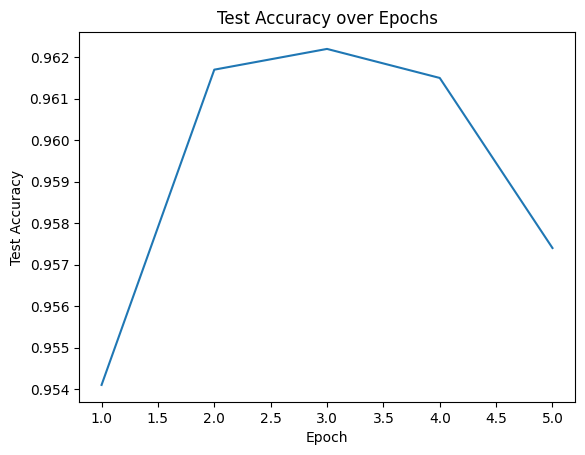

In [57]:
...

## Augmentacja danych (Data Augmentation)

Augmentacja danych to technika, która **sztucznie zwiększa różnorodność zbioru treningowego**, tworząc nowe warianty istniejących obrazów.  
Pomaga to w:
- poprawie generalizacji,
- zmniejszeniu przeuczenia (overfittingu),
- zwiększeniu odporności modelu na zakłócenia.

W przypadku obrazów najczęściej stosuje się drobne, losowe modyfikacje, które **nie zmieniają klasy**, np. obrót cyfry „5” nadal pozostaje „5”.

---

## Augmentacja w PyTorch — `torchvision.transforms`

Biblioteka `torchvision` zawiera gotowe transformacje, które mogą modyfikować obrazy podczas wczytywania danych.

Najczęściej używane transformacje:

### **Przykładowe transformacje:**
- `transforms.RandomHorizontalFlip()` — losowe odbicie lustrzane,
- `transforms.RandomRotation(10)` — losowy obrót o ±10 stopni,
- `transforms.ColorJitter()` — zmiana jasności/kontrastu (dla zdjęć RGB),
- `transforms.RandomCrop()` — losowe przycięcie i ewentualny resize,
- `transforms.RandomAffine()` — kombinacja obrotu, skali i przesunięcia,
- `transforms.Normalize()` — normalizacja pikseli,
- `transforms.ToTensor()` — konwersja obrazu na tensor.

---

## Przykład: augmentacja dla zbioru treningowego

```python
train_transforms = transforms.Compose([
    transforms.RandomRotation(),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])
```

Dataset testowy powinien **nie zawierać augmentacji**, tylko konwersję do tensora:

```python
test_transforms = transforms.ToTensor()
```

---

## Dlaczego augmentacja jest ważna?

- zwiększa odporność modelu na zakłócenia (np. lekki obrót, szum, zmiana oświetlenia),
- pozwala trenować na mniejszej liczbie danych bez spadku jakości,
- zmusza sieć do uczenia cech ogólnych, a nie przypadkowych szczegółów.

---

Augmentacja to praktycznie standard w trenowaniu modeli komputerowego widzenia – szczególnie wtedy, gdy zbiór danych nie jest bardzo duży, jak MNIST.

Zainicjalizujmy więc jeszcze raz nasz Dataset, tym razem z augmentacjami:


In [58]:
train_transforms = transforms.Compose([
    transforms.RandomRotation(40), # rotate +/- 40 degrees
    transforms.RandomHorizontalFlip(p=0.5), # horizontal flip with 50% probability
    transforms.ToTensor()
])

test_transforms = transforms.ToTensor()

train_data = datasets.MNIST(
    root='./data/', # Lokalizacja do przechowania danych
    train=True, # chcemy zbiór treningowy
    download=True, # jeżeli jeszcze nie są pobrane, to pobieramy
    transform=train_transforms,
    target_transform=None # you can transform labels as well
)
# Setup testing data
test_data = datasets.MNIST(
    root='./data/',
    train=False, # jak nie chcemy zbiory treningowego, to znaczy że chcemy testowy
    download=True,
    transform=test_transforms
)

Zobaczmy jak wygląda kilka augmentowanych rysunków:

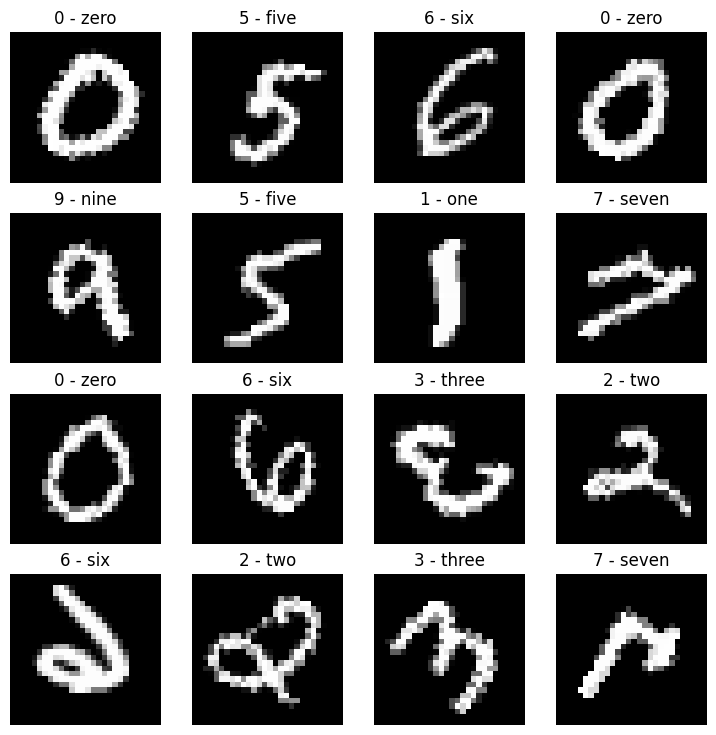

In [59]:
# Plot more images
torch.manual_seed(99)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

**Proszę**:
1. Wykorzystując swój wcześniejszy model, zbadaj wpływ augmentacji zbioru treningowego na wynik klasyfikacji. 
2. Narysuj historię ACC dla obu przypadków - z augmentacją i bez.